In [1]:
import pandas as pd
import numpy as np
import sklearn.preprocessing
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.neighbors import KNeighborsRegressor
import os
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse
import torch

import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from cuml.manifold import UMAP
from cuml.decomposition import TruncatedSVD

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/outputs/gene_trajectories_100.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 66.3 ms, sys: 8.86 s, total: 8.92 s
Wall time: 11.1 s


AnnData object with n_obs × n_vars = 114900 × 15906
    obs: 'time', 'cell_idx'

# Add some metadata, create average trajectory

In [3]:
%%time

total_time = 22 # in hours
bin_every = 0.5 # how many hours
total_bins = int(total_time / bin_every)

print(f"Total time: {total_time} h")
print(f"Bin width : {bin_every} h")
print(f"Total bins: {total_bins}")

scaler = MinMaxScaler(feature_range=(0, 1))
adata.obs['time_norm'] = scaler.fit_transform(adata.obs[['time']])  
adata.obs['time_hours'] =  adata.obs['time_norm'] * total_time

grid_step = bin_every
upper = total_time - grid_step  # exclude the top edge to keep total_bins values

x = adata.obs["time_hours"].to_numpy(dtype=float)
adata.obs["time_bin"] = np.clip(
    np.round(x / grid_step) * grid_step,
    0.0,
    upper,
)

""" generate mean trajectory """
rsc.get.anndata_to_GPU(adata)
aggdata = rsc.get.aggregate(
    adata, 
    by="time_bin",
    func="mean",
)

aggdata.X = aggdata.layers['mean']
aggdata

Total time: 22 h
Bin width : 0.5 h
Total bins: 44
CPU times: user 1.63 s, sys: 5.48 s, total: 7.11 s
Wall time: 7.17 s


AnnData object with n_obs × n_vars = 44 × 15906
    obs: 'time_bin'
    layers: 'mean'

# LTI Dynamics (DMD)

In [4]:
%%time
def dmd_gpu(X, r=None, device="cuda", eps=1e-12, verbose=0):
    """
    Dynamic Mode Decomposition (DMD) on GPU.
    Returns: Phi (c64), lam (c64), W (c64), A_tilde (f32), A (f32)
    """
    def _p(msg, lvl=1):
        if verbose >= lvl:
            print(msg)

    _p(f"[DMD] device={device}", 1)

    # to device (real math)
    X = torch.as_tensor(X, dtype=torch.float32, device=device)
    X1, X2 = X[:, :-1], X[:, 1:]
    if verbose >= 2:
        n, m = X.shape
        _p(f"[DMD] X shape = {tuple(X.shape)} (n_features={n}, m_snapshots={m})", 2)

    # SVD of X1 (real)
    _p("[DMD] SVD(X1)...", 1)
    U, S, Vh = torch.linalg.svd(X1, full_matrices=False)
    r_eff = U.shape[1] if r is None else min(r, U.shape[1])
    if r is not None:
        U, S, Vh = U[:, :r_eff], S[:r_eff], Vh[:r_eff, :]
    V = Vh.mT
    _p(f"[DMD] rank r = {r_eff}", 1)
    if verbose >= 2:
        _p(f"[DMD] U {tuple(U.shape)}, S {tuple(S.shape)}, V {tuple(V.shape)}", 2)

    # Σ^{-1} with safeguard (real)
    S_inv = torch.where(S > eps, 1.0 / S, torch.zeros_like(S))

    # Reduced operator A_tilde = U^T X2 V Σ^{-1} (real)
    _p("[DMD] forming A_tilde...", 1)
    A_tilde = (U.mT @ X2) @ (V * S_inv)

    # Eigen-decomposition in reduced space (complex outputs)
    _p("[DMD] eig(A_tilde)...", 1)
    lam, W = torch.linalg.eig(A_tilde)  # complex

    # Precompute B = X2 V Σ^{-1} (real), then cast ONLY for complex matmul with W
    _p("[DMD] modes Phi...", 1)
    B = X2 @ (V * S_inv)               # (n, r) float32
    Phi = B.to(torch.complex64) @ W    # (n, r) complex64

    # Full-space least-squares transition A = B U^T (real)
    _p("[DMD] full-space A...", 1)
    A = B @ U.mT                       # (n, n) float32

    # Dtypes/outputs
    Phi = Phi.to(torch.complex64)
    lam = lam.to(torch.complex64)
    W = W.to(torch.complex64)
    A_tilde = A_tilde.to(torch.float32)
    A = A.to(torch.float32)

    if verbose >= 2:
        _p(f"[DMD] Phi {tuple(Phi.shape)}, lam {tuple(lam.shape)}, W {tuple(W.shape)}", 2)
        _p(f"[DMD] A_tilde {tuple(A_tilde.shape)}, A {tuple(A.shape)}", 2)

    _p("[DMD] done.", 1)
    return Phi, lam, W, A_tilde, A

Phi, lam, W, A_tilde, A = dmd_gpu(aggdata.X.T, r=18, verbose=2)
print(f"{Phi.shape=}")
print(f"{lam.shape=}")
print(f"{W.shape=}")
print(f"{A_tilde.shape=}")
print(f"{A.shape=}")

[DMD] device=cuda
[DMD] X shape = (15906, 44) (n_features=15906, m_snapshots=44)
[DMD] SVD(X1)...
[DMD] rank r = 18
[DMD] U (15906, 18), S (18,), V (43, 18)
[DMD] forming A_tilde...
[DMD] eig(A_tilde)...
[DMD] modes Phi...
[DMD] full-space A...
[DMD] Phi (15906, 18), lam (18,), W (18, 18)
[DMD] A_tilde (18, 18), A (15906, 15906)
[DMD] done.
Phi.shape=torch.Size([15906, 18])
lam.shape=torch.Size([18])
W.shape=torch.Size([18, 18])
A_tilde.shape=torch.Size([18, 18])
A.shape=torch.Size([15906, 15906])
CPU times: user 76.4 ms, sys: 89.9 ms, total: 166 ms
Wall time: 167 ms


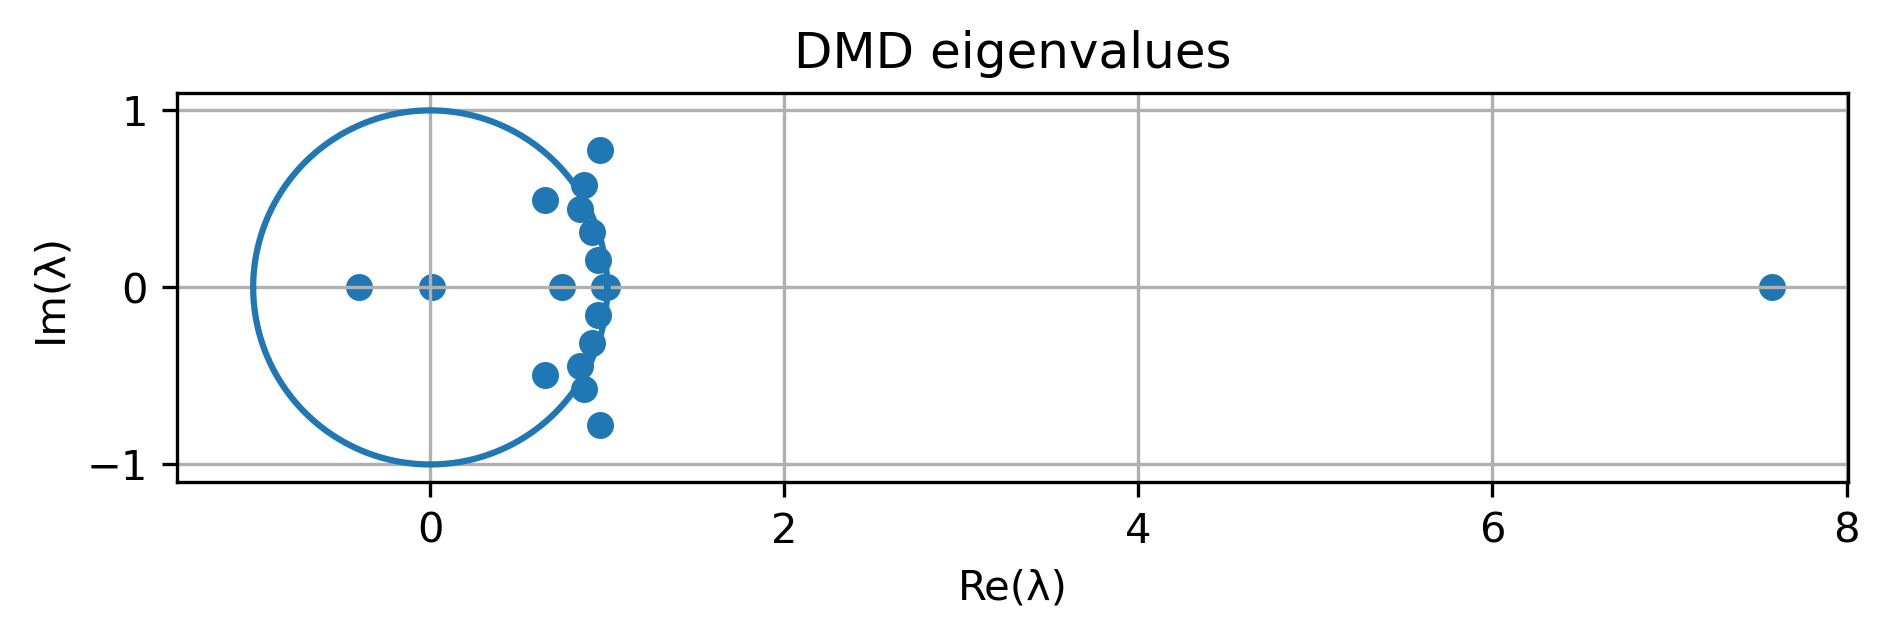

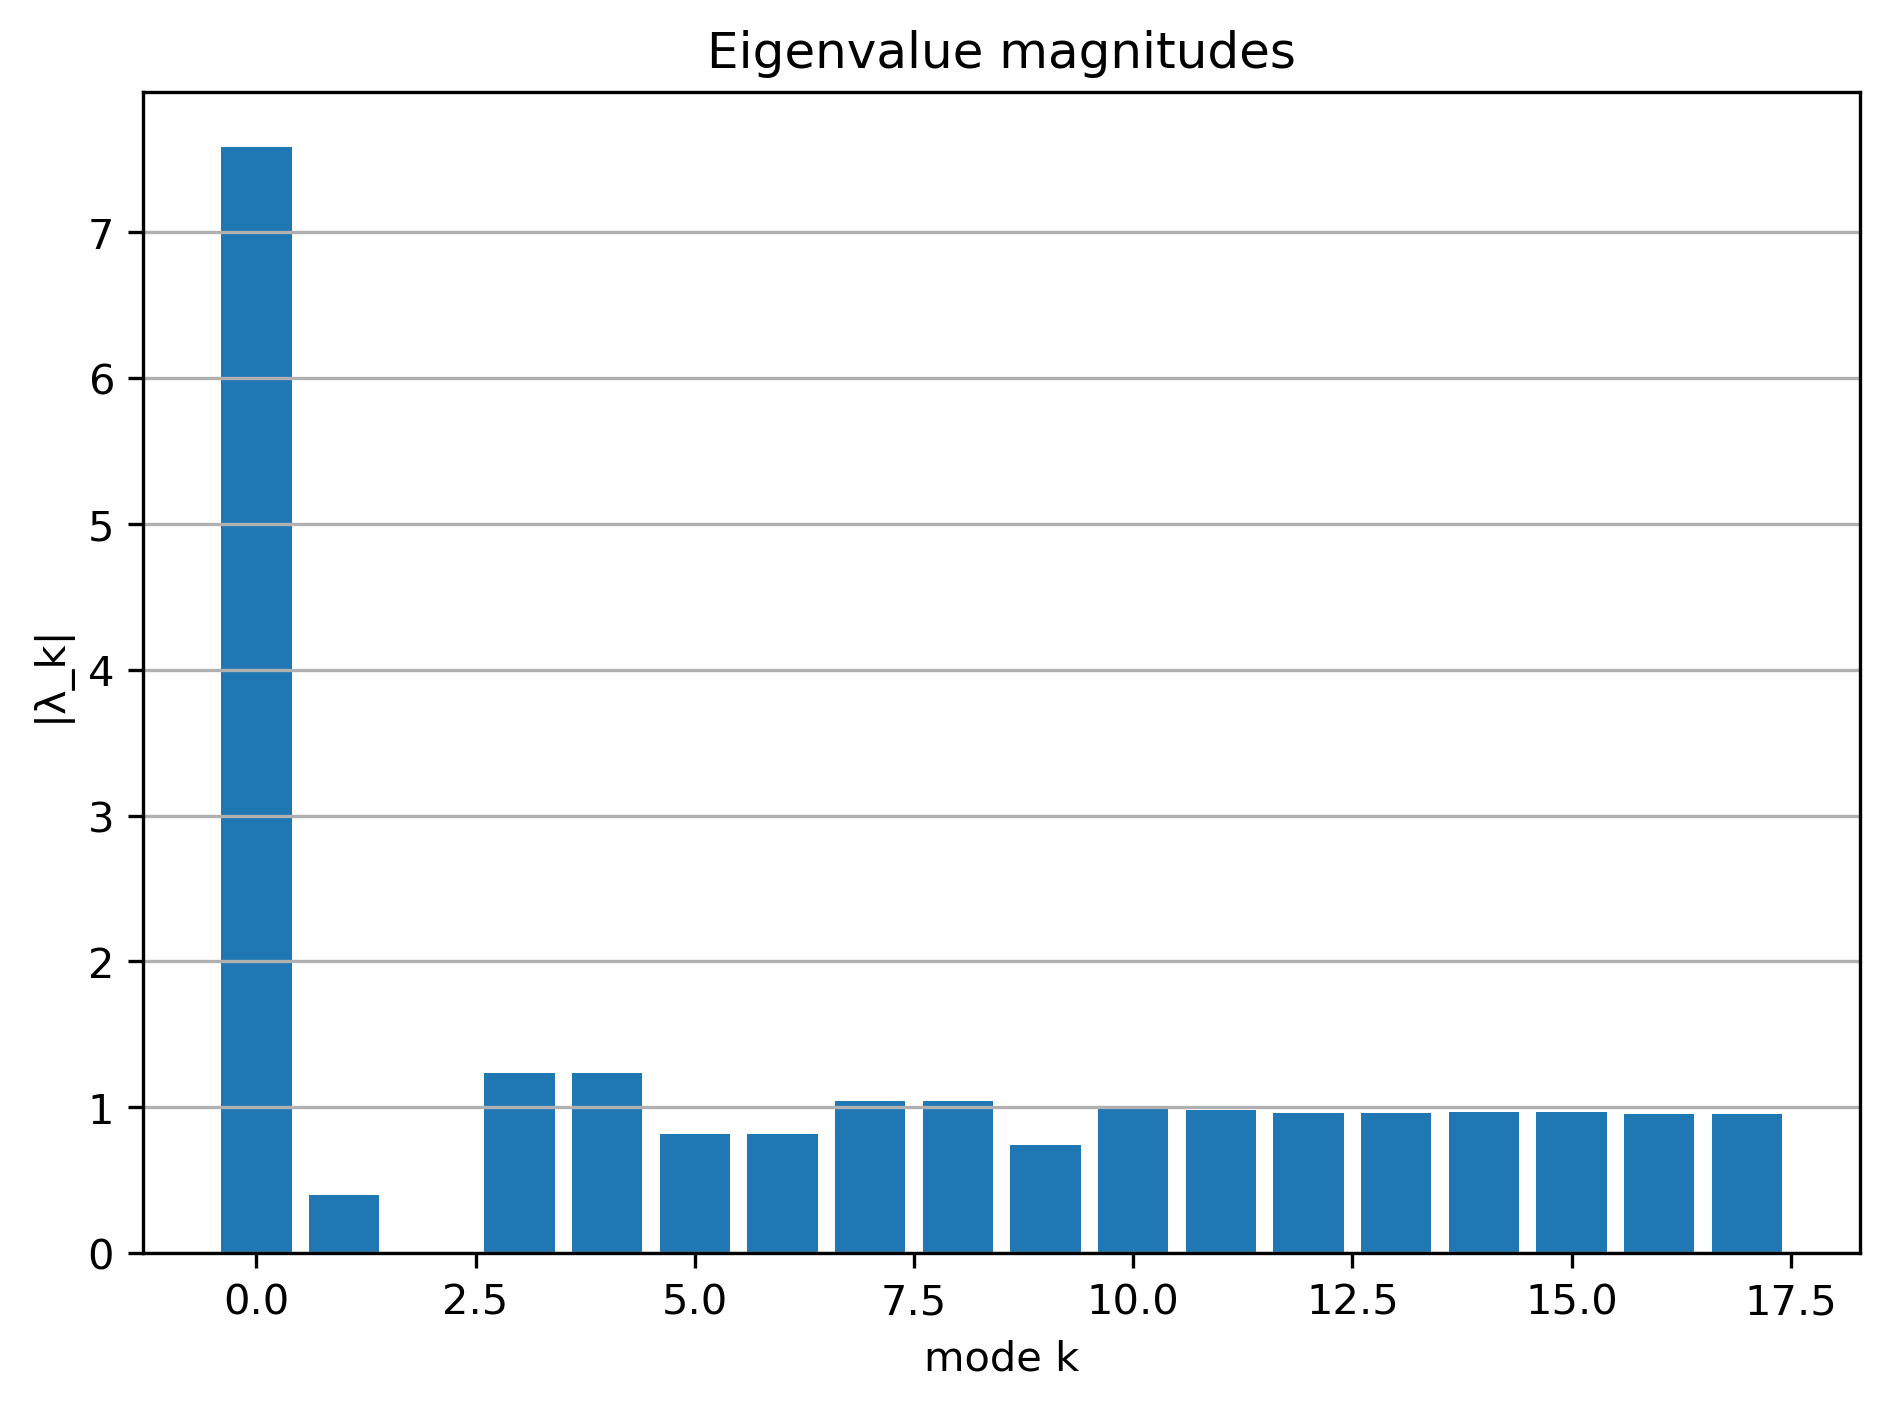

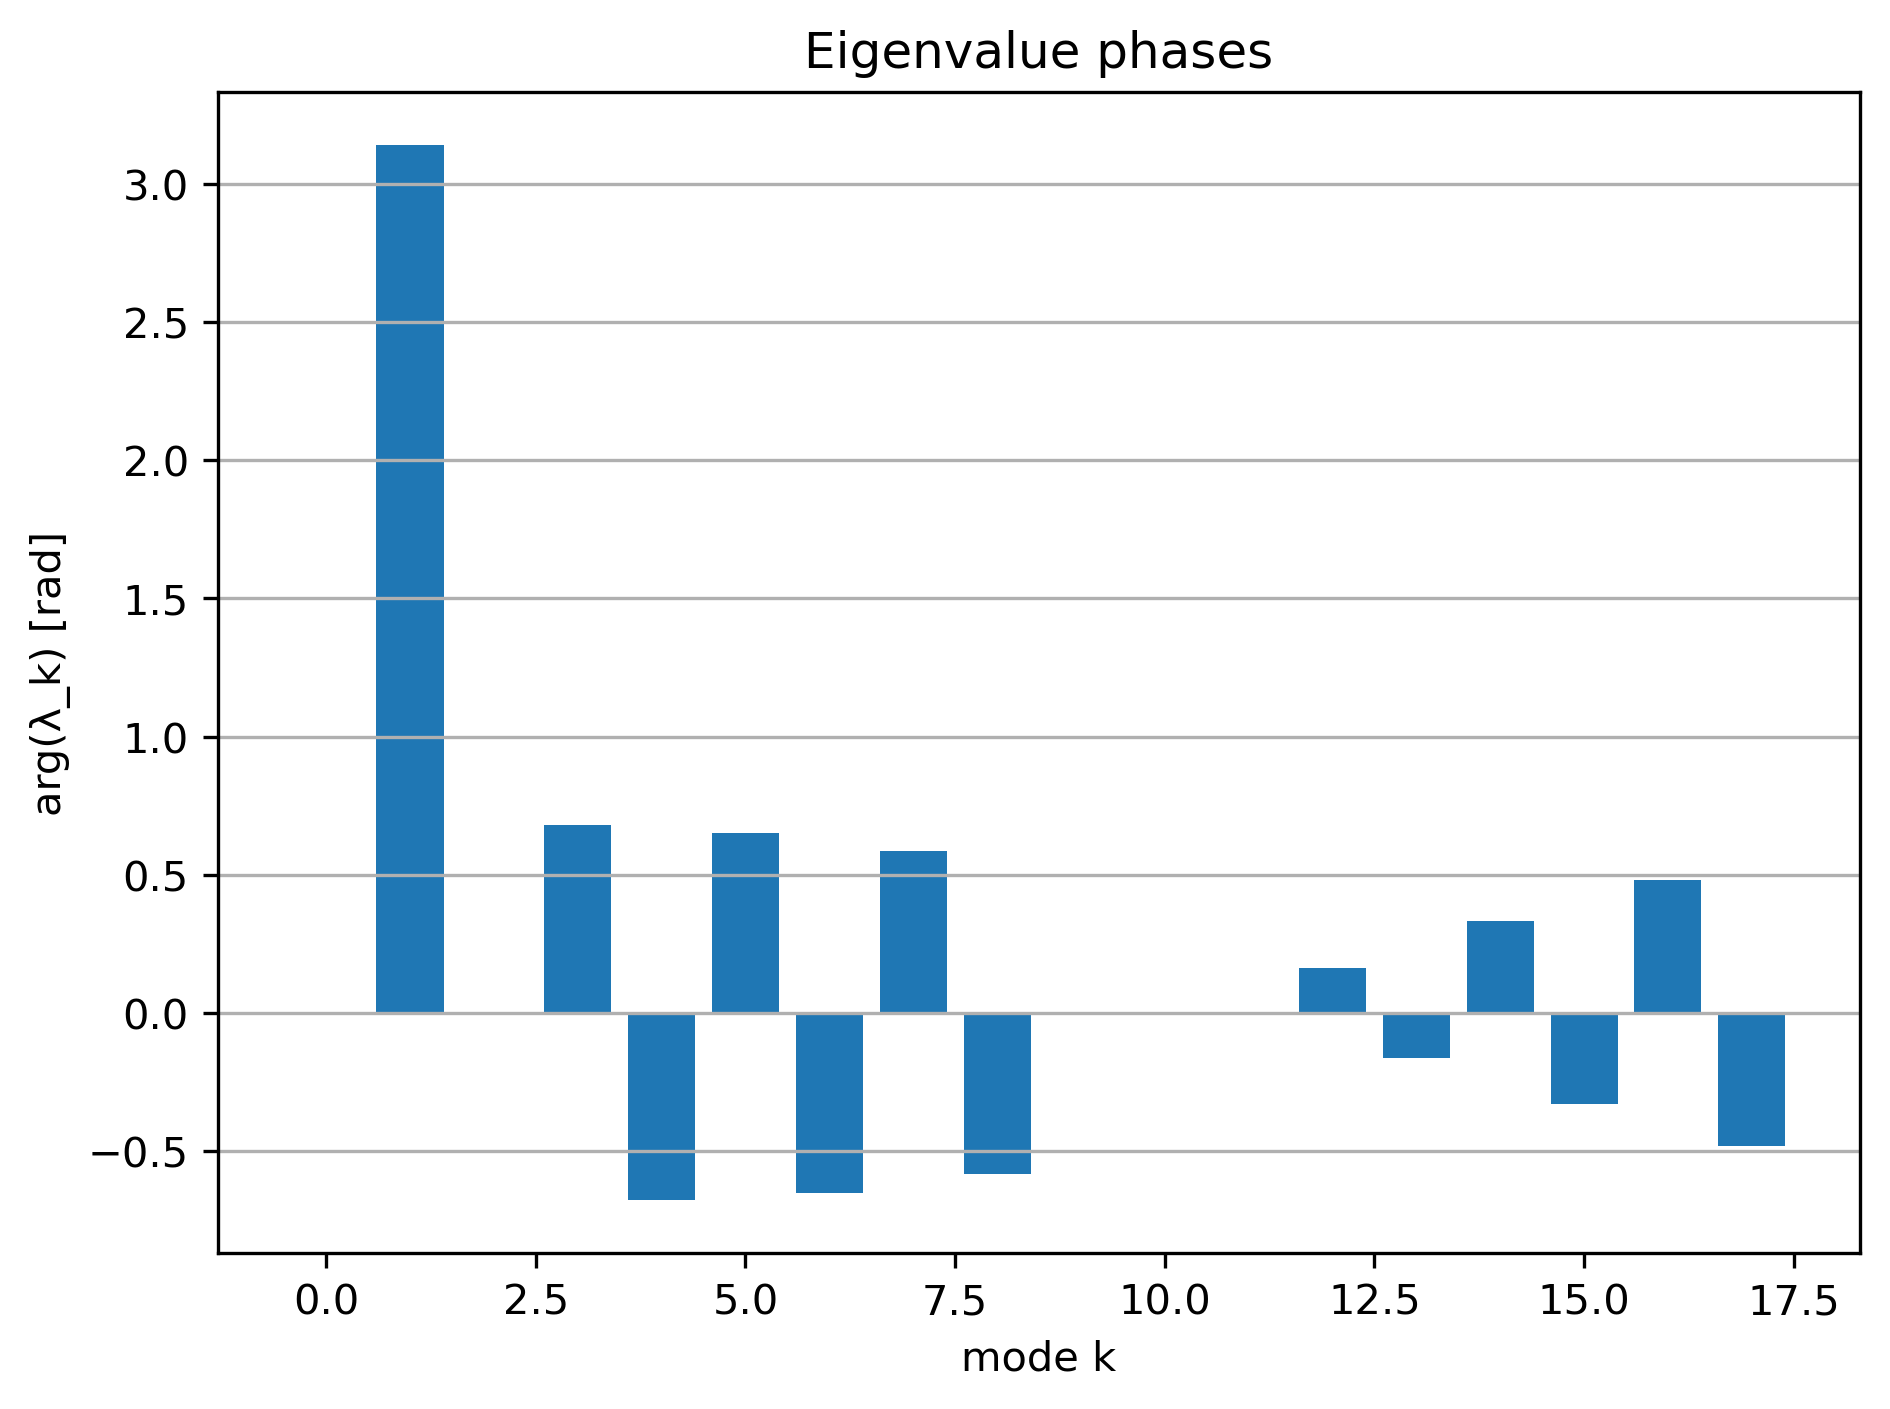

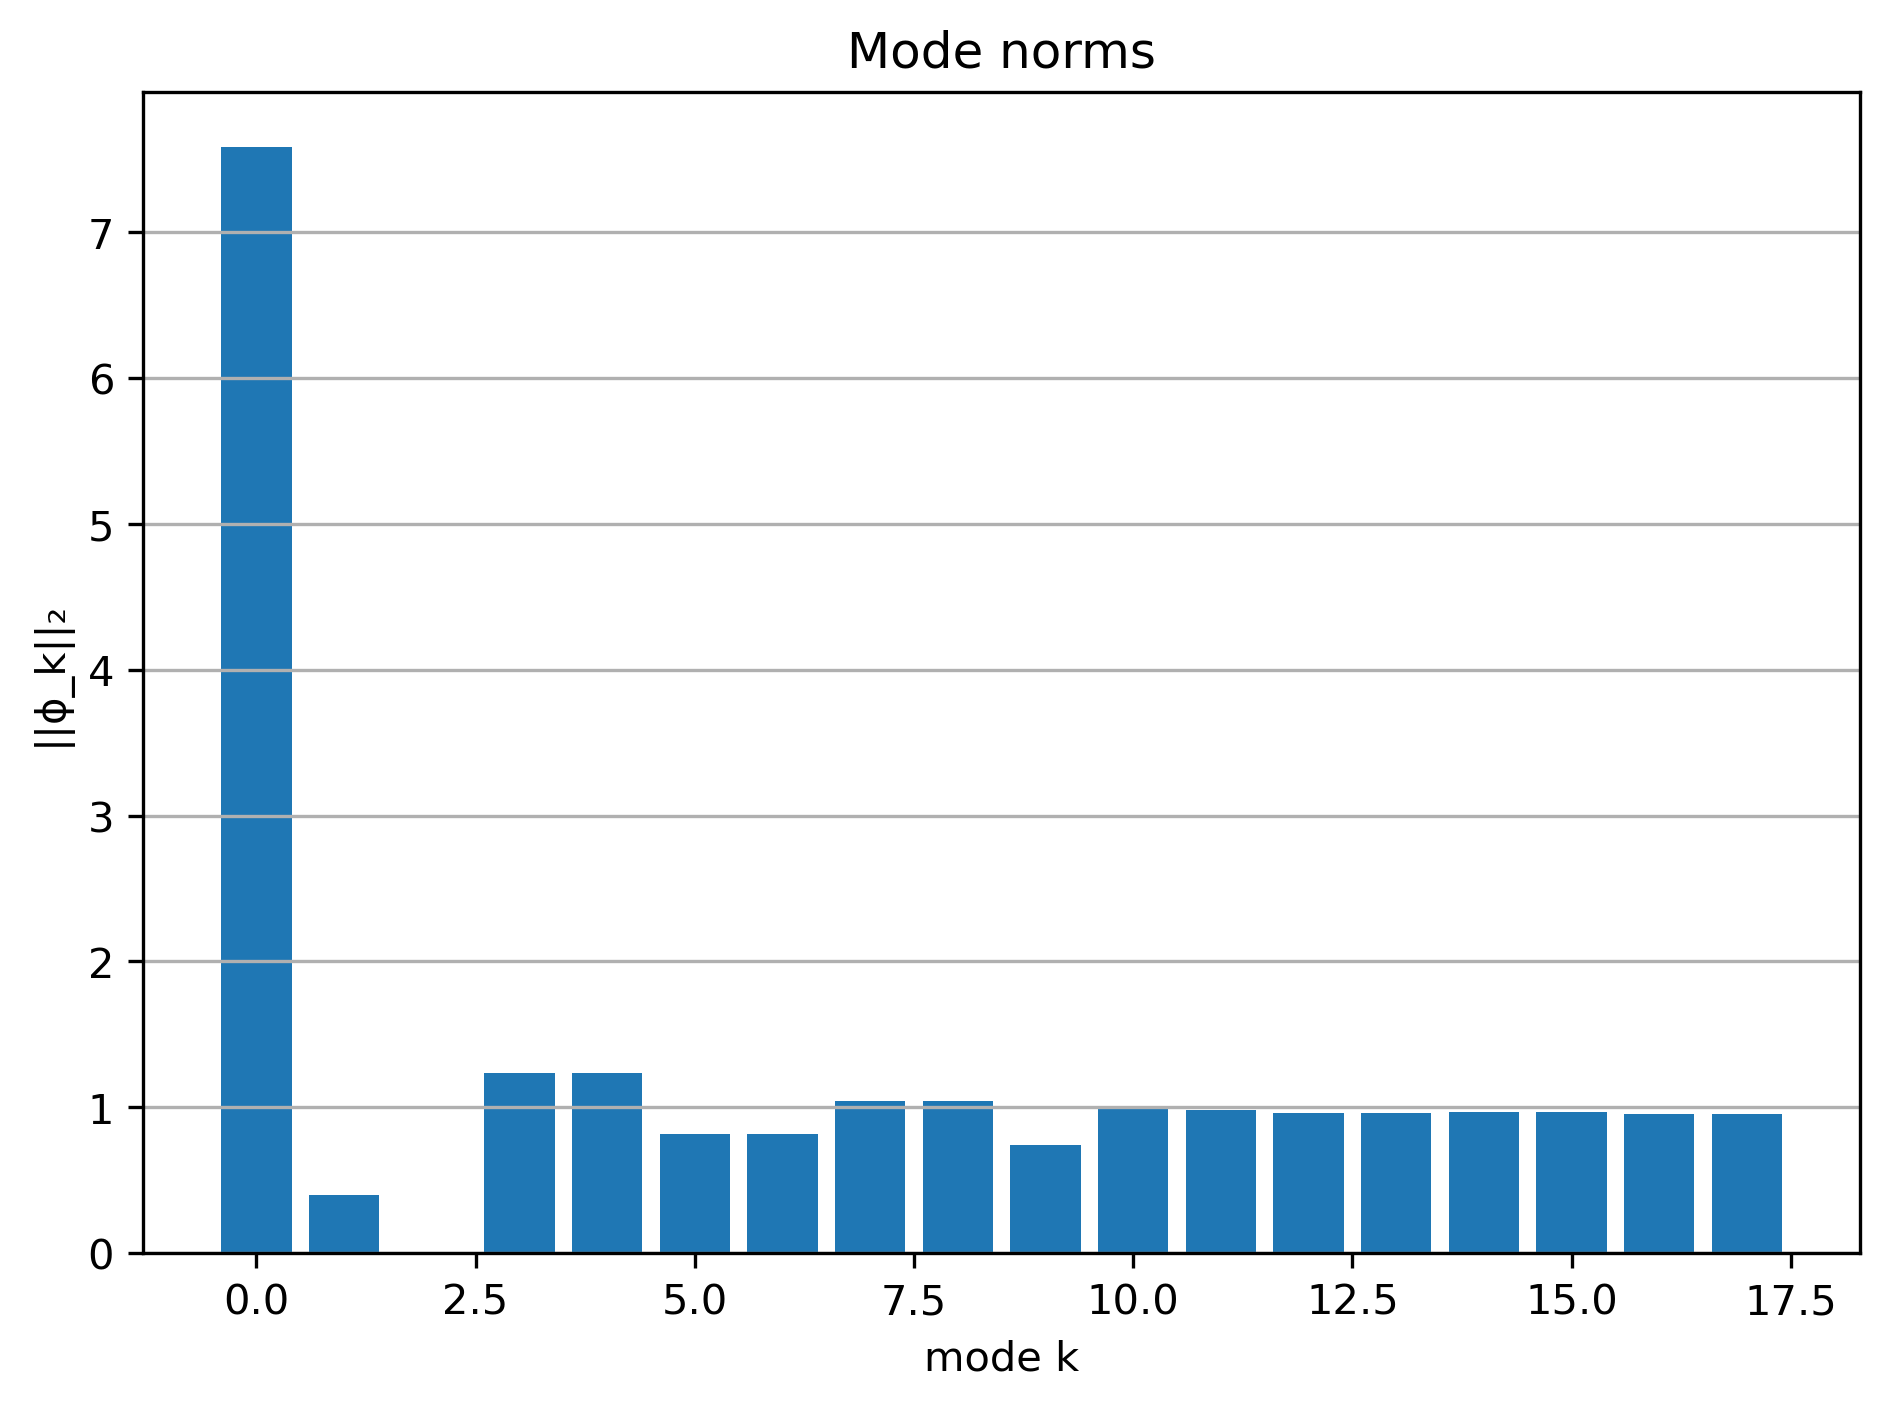

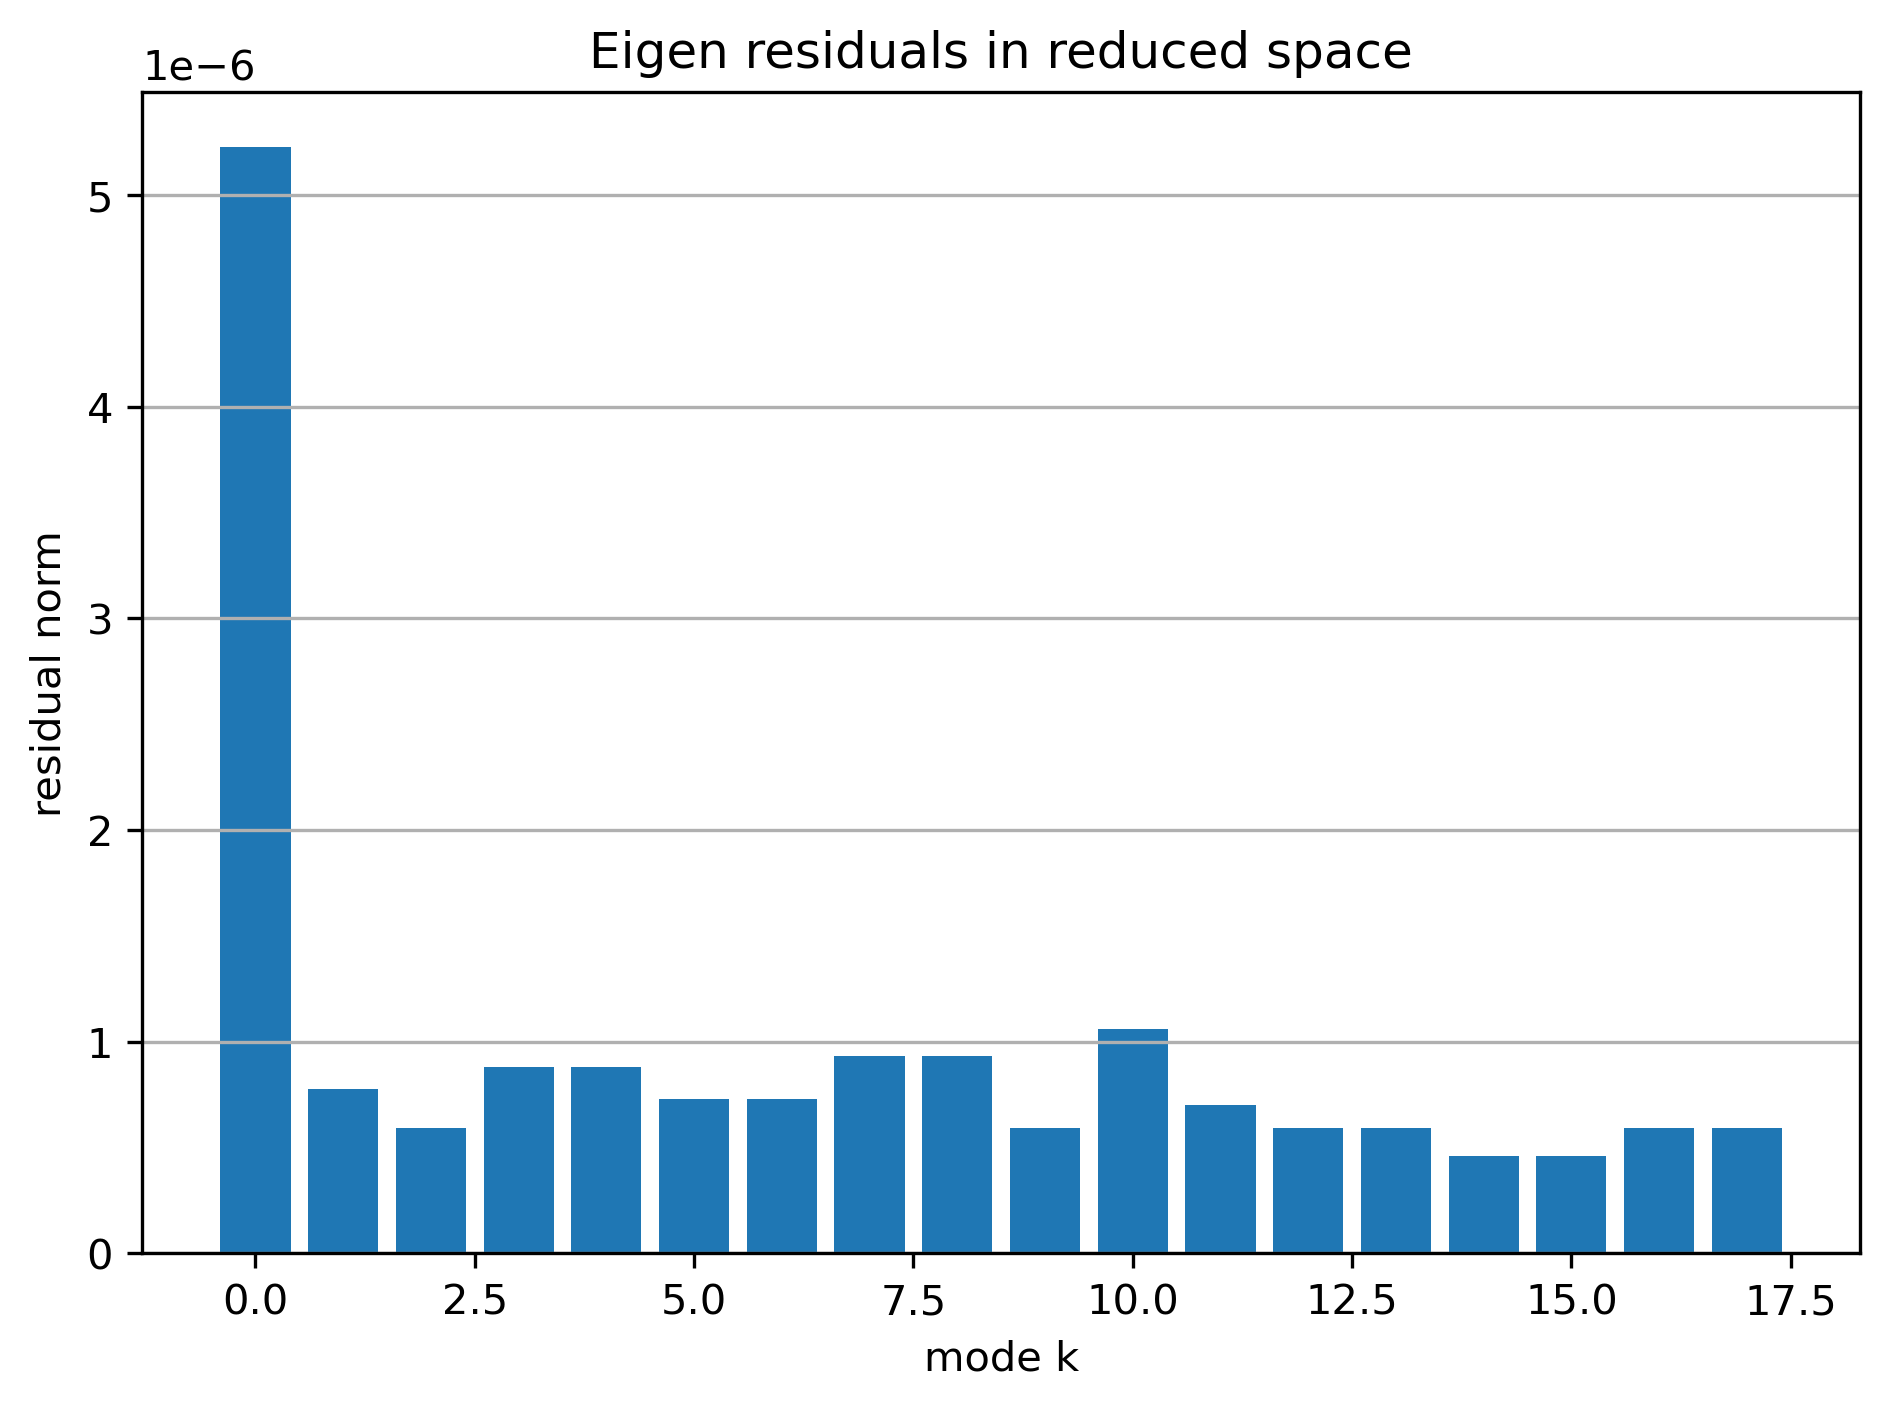

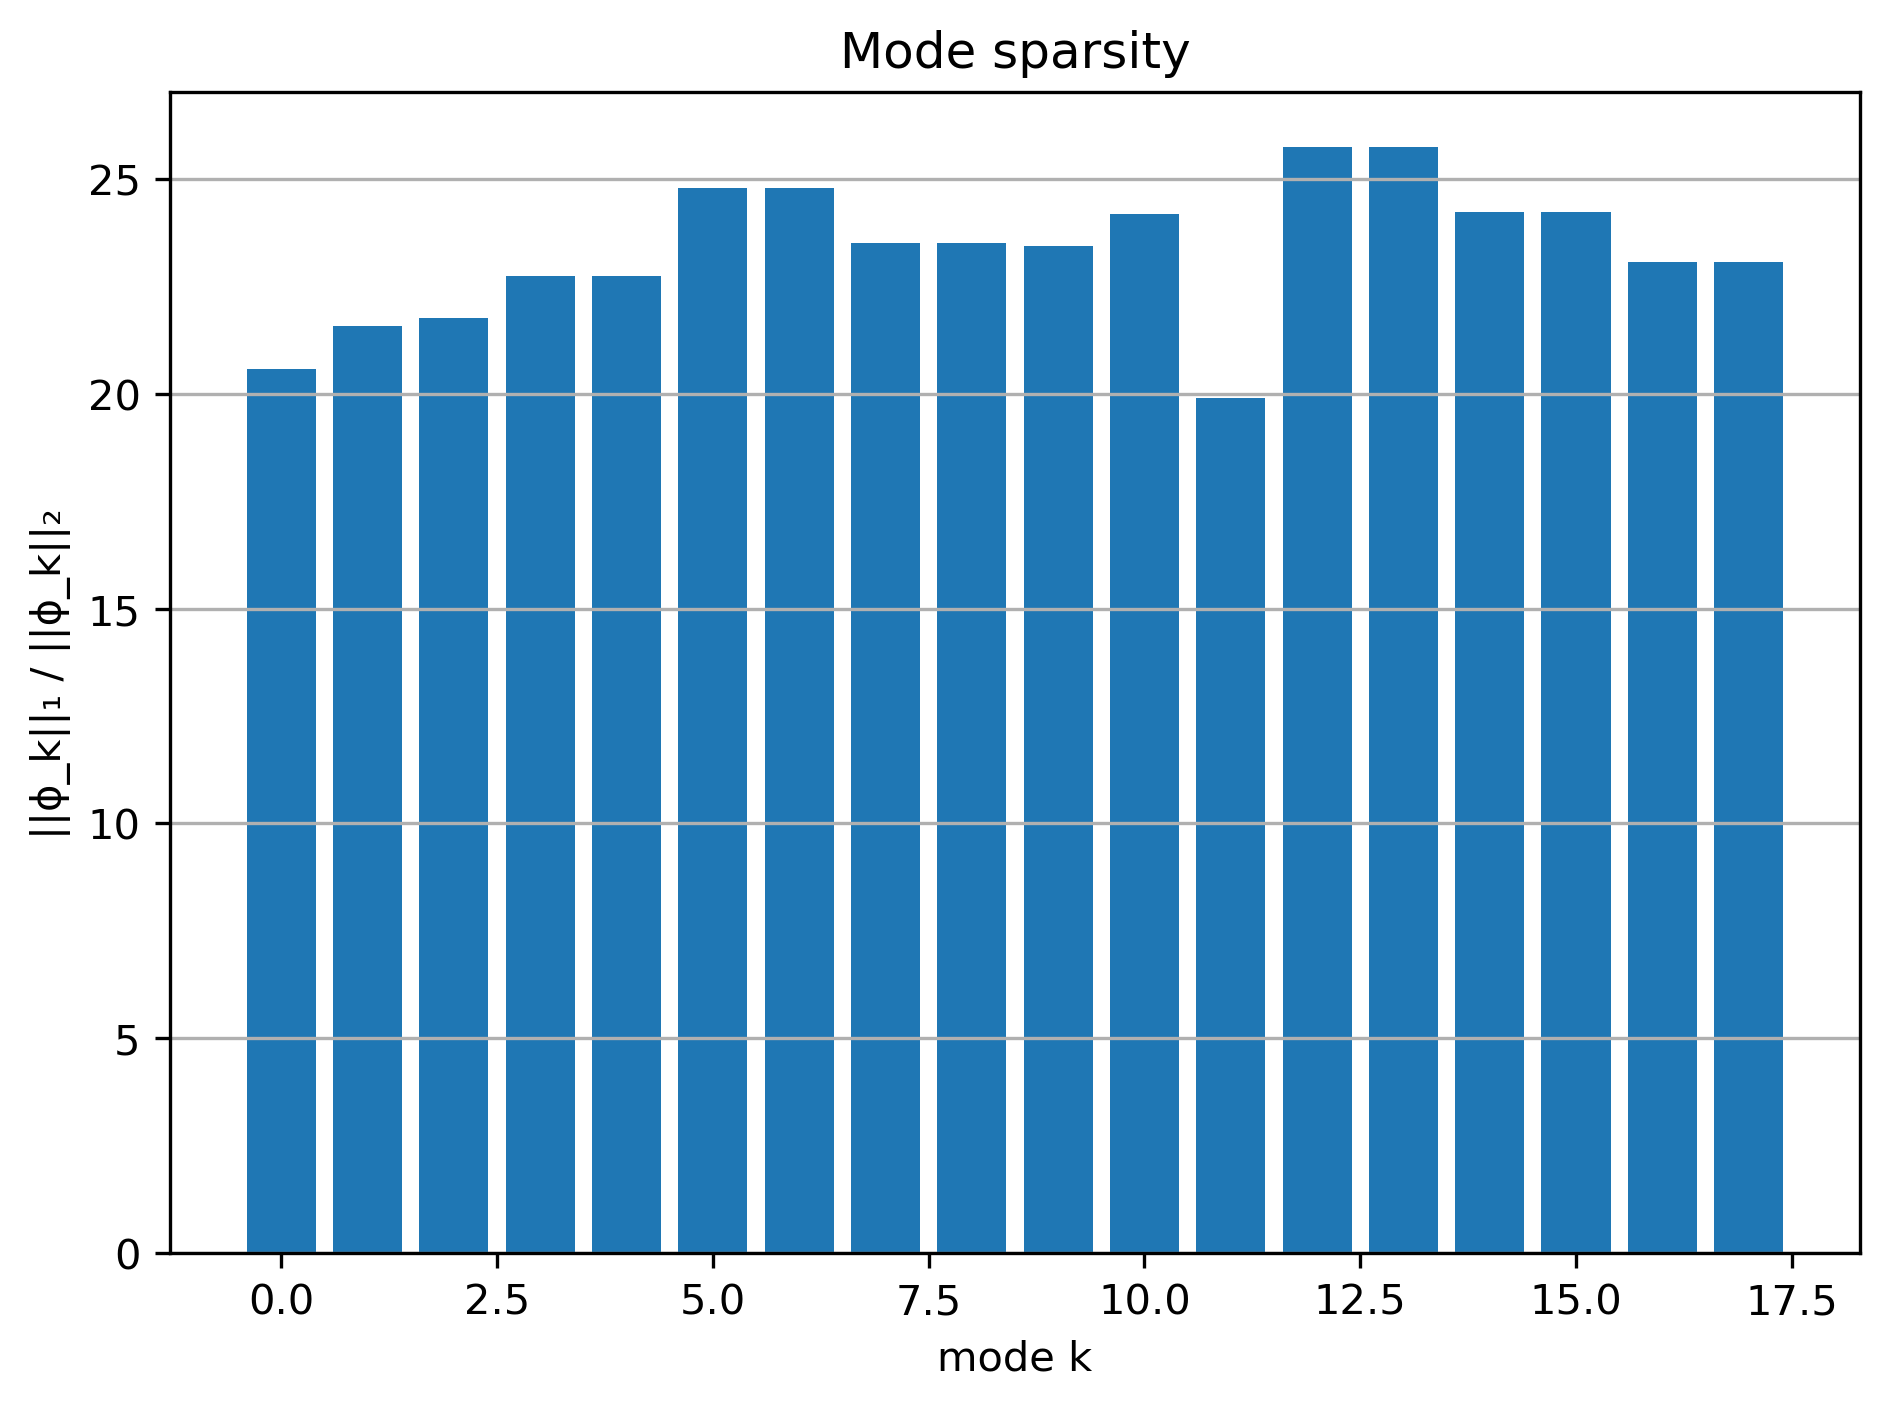

r = 18
spectral radius = 7.580925
modes with |λ|>1: 6/18
median eigen residual: 7.137e-07
CPU times: user 1.06 s, sys: 120 ms, total: 1.18 s
Wall time: 1.2 s


In [5]:
%%time
plt.rcParams["figure.dpi"] = 300

def dmd_diagnostics(Phi, lam, W, A_tilde):
    # --- to numpy (keep complex where needed) ---
    lam_np = lam.detach().cpu().numpy()
    W_np   = W.detach().cpu().numpy()
    Phi_np = Phi.detach().cpu().numpy()
    At_np  = A_tilde.detach().cpu().numpy()

    r = lam_np.shape[0]
    idx = np.arange(r)

    # Eigenvalue geometry
    radii  = np.abs(lam_np)
    angles = np.angle(lam_np)

    # 1) Eigenvalues on complex plane + unit circle
    plt.figure()
    theta = np.linspace(0, 2*np.pi, 512)
    plt.plot(np.cos(theta), np.sin(theta))      # unit circle
    plt.scatter(lam_np.real, lam_np.imag, s=30, zorder=1) # eigenvalues
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('Re(λ)'); plt.ylabel('Im(λ)')
    plt.title('DMD eigenvalues')
    plt.grid(True, zorder=-1)
    plt.tight_layout(); plt.show()

    # 2) |λ| (growth/decay)
    plt.figure()
    plt.bar(idx, radii, zorder=1)
    plt.xlabel('mode k'); plt.ylabel('|λ_k|')
    plt.title('Eigenvalue magnitudes')
    plt.grid(True, axis='y', zorder=-1)
    plt.tight_layout(); plt.show()

    # 3) arg(λ) (phase / oscillation)
    plt.figure()
    plt.bar(idx, angles, zorder=1)
    plt.xlabel('mode k'); plt.ylabel('arg(λ_k) [rad]')
    plt.title('Eigenvalue phases')
    plt.grid(True, axis='y', zorder=-1)
    plt.tight_layout(); plt.show()

    # 4) Mode energy: ||ϕ_k||_2
    phi_norms = np.linalg.norm(Phi_np, axis=0)
    plt.figure()
    plt.bar(idx, phi_norms, zorder=1)
    plt.xlabel('mode k'); plt.ylabel('||ϕ_k||₂')
    plt.title('Mode norms')
    plt.grid(True, axis='y', zorder=-1)
    plt.tight_layout(); plt.show()

    # 5) Reduced-space eigen residuals: ||A_tilde W_k - λ_k W_k||_2
    res = np.empty(r, dtype=float)
    for k in range(r):
        wk = W_np[:, k]
        res[k] = np.linalg.norm(At_np @ wk - lam_np[k] * wk)
    plt.figure()
    plt.bar(idx, res, zorder=1)
    plt.xlabel('mode k'); plt.ylabel('residual norm')
    plt.title('Eigen residuals in reduced space')
    plt.grid(True, axis='y', zorder=-1)
    plt.tight_layout(); plt.show()

    # 6) Mode sparsity proxy: ||ϕ||₁ / ||ϕ||₂
    l1_over_l2 = (np.linalg.norm(Phi_np, ord=1, axis=0) /
                  (np.linalg.norm(Phi_np, axis=0) + 1e-12))
    plt.figure()
    plt.bar(idx, l1_over_l2, zorder=1)
    plt.xlabel('mode k'); plt.ylabel('||ϕ_k||₁ / ||ϕ_k||₂')
    plt.title('Mode sparsity')
    plt.grid(True, axis='y', zorder=-1)
    plt.tight_layout(); plt.show()

    # Text summary
    print(f"r = {r}")
    print(f"spectral radius = {radii.max():.6f}")
    print(f"modes with |λ|>1: {(radii > 1.0 + 1e-6).sum()}/{r}")
    print(f"median eigen residual: {np.median(res):.3e}")

dmd_diagnostics(Phi, lam, W, A_tilde)

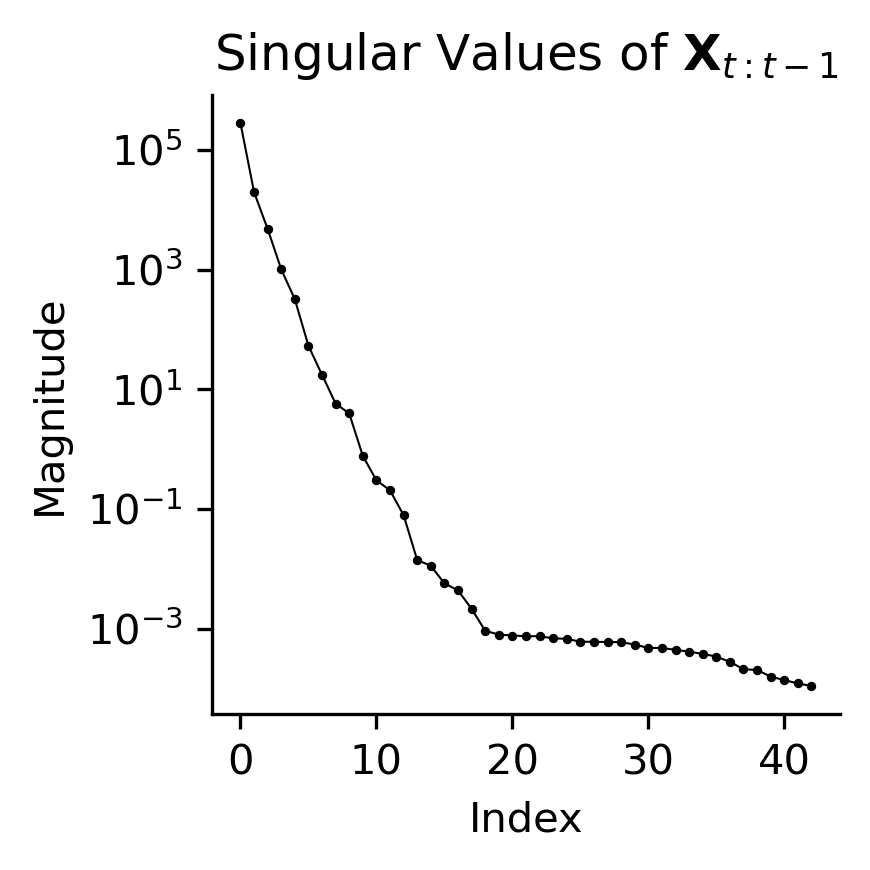

sval.max()=281711.3438 sval.min()=0.0001


In [6]:
def plot_svals(S, title=r"Singular Values of $\mathbf{X}}$", logy=False):
    s = S.detach().cpu().numpy() if hasattr(S, "detach") else np.asarray(S)
    plt.rcParams["figure.facecolor"] = "None"

    plt.rcParams["figure.figsize"] = (3, 3)
    fig, ax = plt.subplots()
    ax.plot(s, linewidth=0.5, marker=".", markersize=2.5, c='k')
    if logy:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("Magnitude")
    ax.set_xlabel("Index")
    # despine without seaborn
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()

    print(f"sval.max()={s.max():.4f} sval.min()={s.min():.4f}")
    
def compute_and_plot_svals(X, device="cuda", title=r"Singular Values of $\mathbf{X}_{t:t-1}$", logy=False):
    X = torch.as_tensor(X, dtype=torch.float32, device=device)
    X1 = X[:, :-1]
    S = torch.linalg.svdvals(X1)        # singular values only (descending)
    plot_svals(S, title=title, logy=logy)

compute_and_plot_svals(aggdata.X.T, device="cuda", logy=True)

In [7]:
# break

# Time-varying Linear Dynamics

In [8]:
%%time
def compute_A(adata, k=None):
    """
    Build cumulative A matrices from adata.X by iterating t = T-1..1.
    Returns A with shape (T-1, D, D).
    """
    X = np.asarray(adata.X)
    if k is None:
        k, n = X.shape
        k = k - 1
    else:
        _, n = X.shape
        
    I = np.eye(n)
    A = np.zeros((k, n, n))

    for ii, tt in enumerate(range(k - 1, 0, -1)):
        print(f"iter: {ii}...")
        num = np.outer(X[tt] - X[tt - 1], X[tt - 1])
        den = np.dot(X[tt - 1], X[tt - 1])
        M = (num / den) + I
        A[ii] = M if ii == 0 else A[ii - 1] @ M
    return A
    

rsc.get.anndata_to_CPU(aggdata)
A = compute_A(aggdata, k=5)
A.shape

iter: 0...
iter: 1...
iter: 2...
iter: 3...
CPU times: user 5min 1s, sys: 14 s, total: 5min 15s
Wall time: 51.2 s


(5, 15906, 15906)

In [9]:
%%time
def compute_A_gpu(adata, k=None, device="cuda"):
    """
    Compute cumulative A matrices on GPU, store results on CPU.
    Returns A with shape (k, D, D) where k = T-1 if not provided.
    """
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA not available but device='cuda' requested.")

    # --- data prep (CPU) ---
    X = np.asarray(adata.X, dtype=np.float32)
    T, D = X.shape
    if k is None:
        k = T - 1
    k = int(k)
    if k < 1 or k > T - 1:
        raise ValueError(f"k must be in [1, {T-1}], got {k}")

    A_cpu = np.zeros((k, D, D), dtype=np.float32)

    # --- GPU buffers (only what's needed) ---
    dev = torch.device(device)
    I = torch.eye(D, dtype=torch.float32, device=dev)
    C = None  # running product on GPU

    with torch.no_grad():
        start_t = T - 1
        for ii in range(k):
            print(f"iter: {ii}...")
            tt = start_t - ii
            # move only two vectors needed for this step
            xt   = torch.from_numpy(X[tt]).to(dev)
            xtm1 = torch.from_numpy(X[tt - 1]).to(dev)

            num = torch.outer(xt - xtm1, xtm1)           # (D,D)
            den = torch.dot(xtm1, xtm1) + 1e-12          # scalar (avoid /0)
            M = num / den + I

            C = M if C is None else C @ M                # cumulative product on GPU
            A_cpu[ii] = C.cpu().numpy()                  # store to CPU

            # free per-iter GPU tensors
            del xt, xtm1, num, M
            torch.cuda.synchronize() if device == "cuda" else None

    # optional: release GPU memory pressure
    if device == "cuda":
        del I, C
        torch.cuda.empty_cache()

    return A_cpu

k = len(aggdata) - 1
A = compute_A_gpu(aggdata, k=k, device="cuda")
print(A.shape)

iter: 0...
iter: 1...
iter: 2...
iter: 3...
iter: 4...
iter: 5...
iter: 6...
iter: 7...
iter: 8...
iter: 9...
iter: 10...
iter: 11...
iter: 12...
iter: 13...
iter: 14...
iter: 15...
iter: 16...
iter: 17...
iter: 18...
iter: 19...
iter: 20...
iter: 21...
iter: 22...
iter: 23...
iter: 24...
iter: 25...
iter: 26...
iter: 27...
iter: 28...
iter: 29...
iter: 30...
iter: 31...
iter: 32...
iter: 33...
iter: 34...
iter: 35...
iter: 36...
iter: 37...
iter: 38...
iter: 39...
iter: 40...
iter: 41...
iter: 42...
(43, 15906, 15906)
CPU times: user 1min 2s, sys: 28.4 s, total: 1min 30s
Wall time: 1min 30s


In [10]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)